# ใบงานที่ 3 (LAB 1): Regression
## การทำนายอายุ (Age Prediction) จากภาพใบหน้า

**Dataset:** [Age, Gender and Ethnicity (Face Data) CSV](https://www.kaggle.com/datasets/nipunarora8/age-gender-and-ethnicity-face-data-csv)

เนื้อหาในโน้ตบุ๊กนี้ครอบคลุม:
1. Data Preparation & Exploration
2. Simple Linear Regression (1 feature)
3. Multiple Linear Regression (หลาย features)
4. Principal Component Analysis (PCA) เพื่อลดจำนวน features จากพิกเซลภาพ
5. Age Prediction ด้วย Linear Regression บน PCA components
6. การประเมินผลและเปรียบเทียบโมเดล (MSE, RMSE, MAE, R²)

> **หมายเหตุ:** วาง `age_gender.csv` ไว้ในโฟลเดอร์เดียวกับโน้ตบุ๊กนี้ (หรือแก้ path ในเซลล์ถัดไป) ก่อนรัน


In [1]:
# ---- Import libraries ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set(style="whitegrid")
np.random.seed(42)


## 1. Data Preparation & Exploration

In [2]:
# ---- Load dataset ----
DATA_PATH = "age_gender.csv"   # เปลี่ยน path ตรงนี้ถ้าไฟล์อยู่ที่อื่น

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (23705, 5)


,age,ethnicity,gender,img_name,pixels
0,1,2,0,20161219203650636.jpg.chip.jpg,129 128 128 126 127 130 133 135 139 142 145 14...
1,1,2,0,20161219222752047.jpg.chip.jpg,164 74 111 168 169 171 175 182 184 188 193 199...
2,1,2,0,20161219222832191.jpg.chip.jpg,67 70 71 70 69 67 70 79 90 103 116 132 145 155...
3,1,2,0,20161220144911423.jpg.chip.jpg,193 197 198 200 199 200 202 203 204 205 208 21...
4,1,2,0,20161220144914327.jpg.chip.jpg,202 205 209 210 209 209 210 211 212 214 218 21...


In [3]:
df.info()
print()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 23705 entries, 0 to 23704
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        23705 non-null  int64
 1   ethnicity  23705 non-null  int64
 2   gender     23705 non-null  int64
 3   img_name   23705 non-null  str  
 4   pixels     23705 non-null  str  
dtypes: int64(3), str(2)
memory usage: 926.1 KB



,age,ethnicity,gender
count,23705.000000,23705.000000,23705.000000
mean,33.300907,1.269226,0.477283
std,19.885708,1.345638,0.499494
min,1.000000,0.000000,0.000000
25%,23.000000,0.000000,0.000000
50%,29.000000,1.000000,0.000000
75%,45.000000,2.000000,1.000000
max,116.000000,4.000000,1.000000


In [4]:
# ---- แปลงคอลัมน์ pixels (string) ให้เป็น numpy array ของภาพ 48x48 ----
IMG_SIZE = 48

def pixels_to_array(pixel_str):
    return np.array(pixel_str.split(), dtype='float32')

pixel_arrays = np.stack(df['pixels'].apply(pixels_to_array).values)
print("Pixel matrix shape:", pixel_arrays.shape)   # (N, 48*48)

# Normalize พิกเซลให้อยู่ในช่วง 0-1
pixel_arrays = pixel_arrays / 255.0


Pixel matrix shape: (23705, 2304)


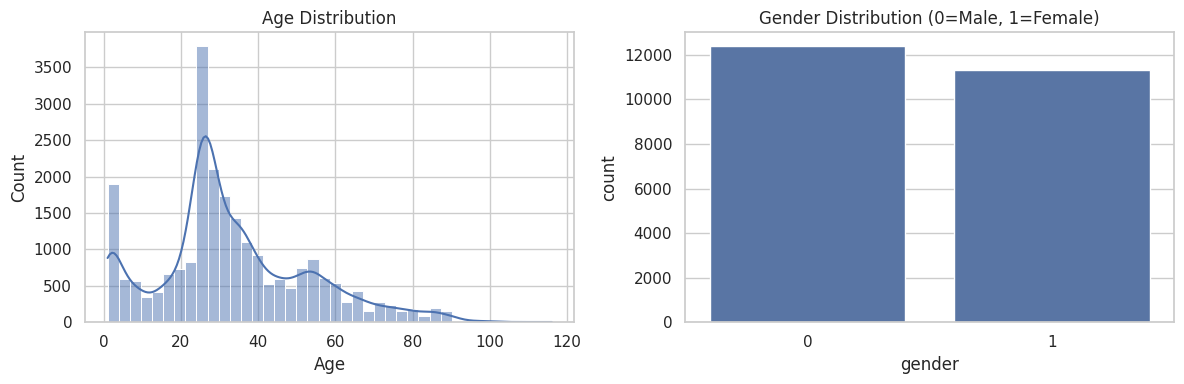

In [5]:
# ---- สำรวจการกระจายตัวของอายุ ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['age'], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")

sns.countplot(x='gender', data=df, ax=axes[1])
axes[1].set_title("Gender Distribution (0=Male, 1=Female)")

plt.tight_layout()
plt.show()


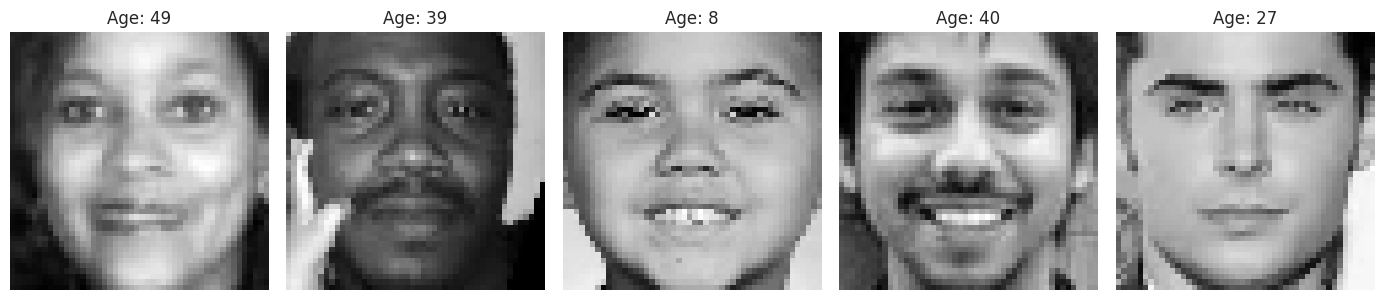

In [6]:
# ---- ดูตัวอย่างภาพใบหน้าพร้อม label อายุ ----
fig, axes = plt.subplots(1, 5, figsize=(14, 3))
sample_idx = np.random.choice(len(df), 5, replace=False)

for ax, idx in zip(axes, sample_idx):
    img = pixel_arrays[idx].reshape(IMG_SIZE, IMG_SIZE)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Age: {df['age'].iloc[idx]}")
    ax.axis('off')

plt.tight_layout()
plt.show()


## 2. Simple Linear Regression

ทดลองสร้างโมเดล Regression แบบพื้นฐานที่สุด โดยใช้ **feature เดียว** ในการทำนายอายุ
เพื่อให้เห็นหลักการของ Simple Linear Regression: `y = b0 + b1*x`

ในที่นี้ใช้ **ค่าความเข้มพิกเซลเฉลี่ย (mean pixel intensity)** ของภาพเป็น feature ตัวแทนง่าย ๆ
(ความเข้มแสง/ความมันวาวของผิว อาจมีความสัมพันธ์คร่าว ๆ กับอายุ)

In [7]:
# ---- สร้าง feature เดียว: mean pixel intensity ----
mean_intensity = pixel_arrays.mean(axis=1)

X_simple = mean_intensity.reshape(-1, 1)
y = df['age'].values

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)
y_pred_s = simple_model.predict(X_test_s)

print(f"Coefficient (b1): {simple_model.coef_[0]:.4f}")
print(f"Intercept   (b0): {simple_model.intercept_:.4f}")


Coefficient (b1): -24.0145
Intercept   (b0): 45.0689


MSE : 382.615
RMSE: 19.561
MAE : 15.211
R^2 : 0.010


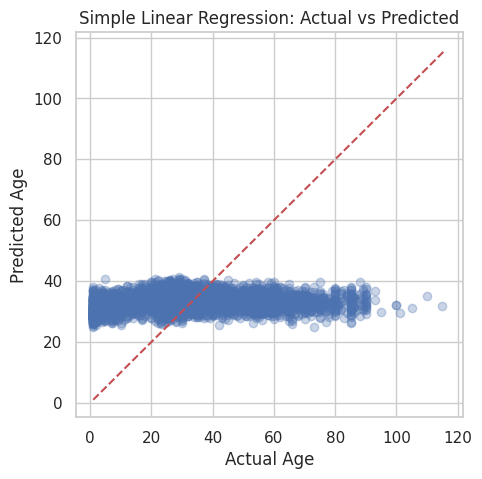

In [8]:
# ---- ประเมินผล Simple Linear Regression ----
mse_s = mean_squared_error(y_test_s, y_pred_s)
rmse_s = np.sqrt(mse_s)
mae_s = mean_absolute_error(y_test_s, y_pred_s)
r2_s = r2_score(y_test_s, y_pred_s)

print(f"MSE : {mse_s:.3f}")
print(f"RMSE: {rmse_s:.3f}")
print(f"MAE : {mae_s:.3f}")
print(f"R^2 : {r2_s:.3f}")

plt.figure(figsize=(5,5))
plt.scatter(y_test_s, y_pred_s, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Simple Linear Regression: Actual vs Predicted")
plt.show()


## 3. Multiple Linear Regression

ขยับมาใช้ **หลาย features** ในการทำนายอายุ: `y = b0 + b1*x1 + b2*x2 + ... + bn*xn`

สร้าง features เชิงสถิติจากภาพ (image statistics) เพิ่มขึ้นมาแทนที่จะใช้แค่ค่าเฉลี่ยตัวเดียว
เช่น ค่าเฉลี่ย, ส่วนเบี่ยงเบนมาตรฐาน, ค่าสูงสุด/ต่ำสุด, และค่าเฉลี่ยของแต่ละส่วนของภาพ (quadrant)

In [9]:
# ---- สร้างหลาย features จากภาพ ----
def extract_features(img_flat, size=IMG_SIZE):
    img = img_flat.reshape(size, size)
    h, w = size // 2, size // 2
    q1 = img[:h, :w].mean()
    q2 = img[:h, w:].mean()
    q3 = img[h:, :w].mean()
    q4 = img[h:, w:].mean()
    return [
        img.mean(),
        img.std(),
        img.min(),
        img.max(),
        q1, q2, q3, q4,
    ]

feature_names = ['mean', 'std', 'min', 'max', 'q1_mean', 'q2_mean', 'q3_mean', 'q4_mean']
X_multi = np.array([extract_features(row) for row in pixel_arrays])

print("Multiple regression feature matrix shape:", X_multi.shape)


Multiple regression feature matrix shape: (23705, 8)


In [10]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

multi_model = LinearRegression()
multi_model.fit(X_train_m, y_train_m)
y_pred_m = multi_model.predict(X_test_m)

coef_table = pd.DataFrame({
    'feature': feature_names,
    'coefficient': multi_model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print("Intercept:", multi_model.intercept_)
coef_table


Intercept: 44.33408


,feature,coefficient
1,std,-47.633904
2,min,28.396297
6,q3_mean,-25.632816
7,q4_mean,-21.303236
4,q1_mean,14.610804
3,max,12.525431
5,q2_mean,7.957661
0,mean,-6.091895


MSE : 365.945
RMSE: 19.130
MAE : 14.799
R^2 : 0.053


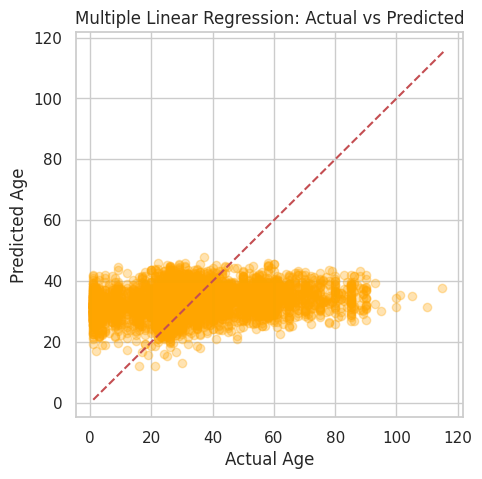

In [11]:
# ---- ประเมินผล Multiple Linear Regression ----
mse_m = mean_squared_error(y_test_m, y_pred_m)
rmse_m = np.sqrt(mse_m)
mae_m = mean_absolute_error(y_test_m, y_pred_m)
r2_m = r2_score(y_test_m, y_pred_m)

print(f"MSE : {mse_m:.3f}")
print(f"RMSE: {rmse_m:.3f}")
print(f"MAE : {mae_m:.3f}")
print(f"R^2 : {r2_m:.3f}")

plt.figure(figsize=(5,5))
plt.scatter(y_test_m, y_pred_m, alpha=0.3, color='orange')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Multiple Linear Regression: Actual vs Predicted")
plt.show()


## 4. Principal Component Analysis (PCA) + Age Prediction

แทนที่จะสร้าง features เชิงสถิติแบบ manual เราสามารถใช้ **ภาพทั้งหมด (raw pixels)** เป็น input
แล้วใช้ **PCA** ลดจำนวนมิติ (2304 พิกเซล) ให้เหลือ features จำนวนน้อยที่ยังคงข้อมูลสำคัญของภาพไว้
ก่อนนำไปเข้า Linear Regression — นี่คือโมเดลหลักสำหรับ **Age Prediction** ในแล็บนี้

In [12]:
# ---- แบ่งข้อมูล train/test บน raw pixels ก่อนทำ PCA (ป้องกัน data leakage) ----
X_train_raw, X_test_raw, y_train_p, y_test_p = train_test_split(
    pixel_arrays, y, test_size=0.2, random_state=42
)

# ---- Standardize ----
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# ---- PCA ----
N_COMPONENTS = 50
pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Explained variance with {N_COMPONENTS} components: "
      f"{pca.explained_variance_ratio_.sum()*100:.2f}%")


Explained variance with 50 components: 87.47%


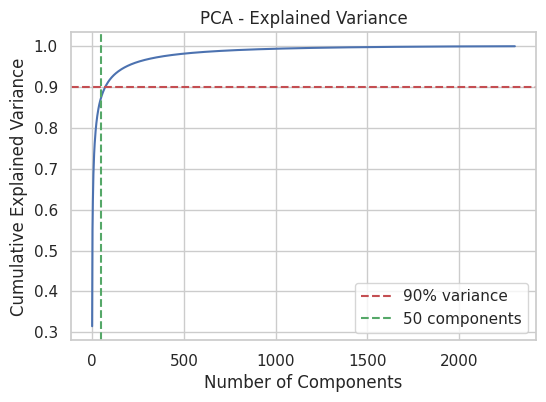

In [13]:
# ---- กราฟ Cumulative Explained Variance เพื่อเลือกจำนวน components ที่เหมาะสม ----
pca_full = PCA().fit(X_train_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(6,4))
plt.plot(cumvar)
plt.axhline(0.90, color='r', linestyle='--', label='90% variance')
plt.axvline(N_COMPONENTS, color='g', linestyle='--', label=f'{N_COMPONENTS} components')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Explained Variance")
plt.legend()
plt.show()


MSE : 239.562
RMSE: 15.478
MAE : 12.024
R^2 : 0.380


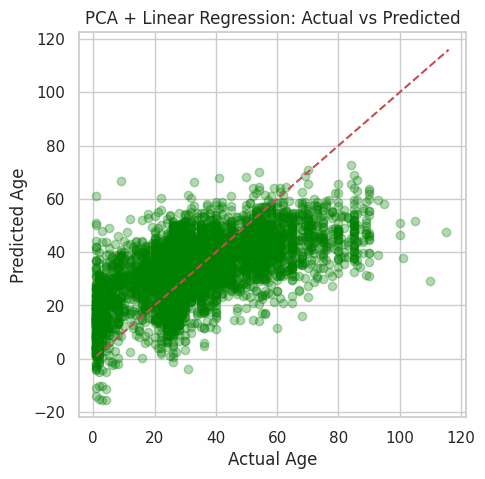

In [14]:
# ---- Age Prediction: Linear Regression บน PCA components ----
pca_model = LinearRegression()
pca_model.fit(X_train_pca, y_train_p)
y_pred_p = pca_model.predict(X_test_pca)

mse_p = mean_squared_error(y_test_p, y_pred_p)
rmse_p = np.sqrt(mse_p)
mae_p = mean_absolute_error(y_test_p, y_pred_p)
r2_p = r2_score(y_test_p, y_pred_p)

print(f"MSE : {mse_p:.3f}")
print(f"RMSE: {rmse_p:.3f}")
print(f"MAE : {mae_p:.3f}")
print(f"R^2 : {r2_p:.3f}")

plt.figure(figsize=(5,5))
plt.scatter(y_test_p, y_pred_p, alpha=0.3, color='green')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("PCA + Linear Regression: Actual vs Predicted")
plt.show()


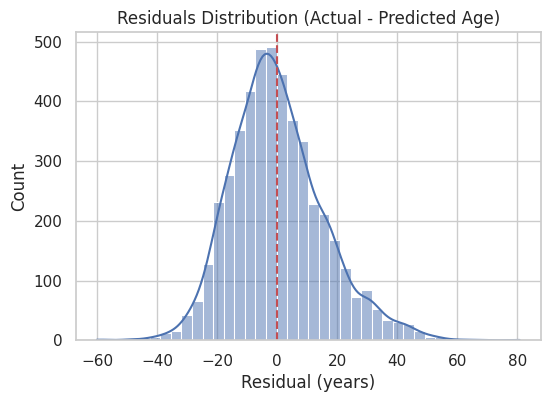

In [15]:
# ---- ตรวจสอบ residuals (ข้อผิดพลาดของโมเดล) ----
residuals = y_test_p - y_pred_p

plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=40, kde=True)
plt.axvline(0, color='r', linestyle='--')
plt.title("Residuals Distribution (Actual - Predicted Age)")
plt.xlabel("Residual (years)")
plt.show()


## 5. เปรียบเทียบผลลัพธ์ของแต่ละโมเดล

In [16]:
results = pd.DataFrame({
    'Model': [
        'Simple Linear Regression (1 feature)',
        'Multiple Linear Regression (8 features)',
        f'PCA ({N_COMPONENTS} components) + Linear Regression'
    ],
    'MSE': [mse_s, mse_m, mse_p],
    'RMSE': [rmse_s, rmse_m, rmse_p],
    'MAE': [mae_s, mae_m, mae_p],
    'R^2': [r2_s, r2_m, r2_p],
})
results


,Model,MSE,RMSE,MAE,R^2
0,Simple Linear Regression (1 feature),382.614838,19.560543,15.211040,0.010047
1,Multiple Linear Regression (8 features),365.945435,19.129700,14.799329,0.053177
2,PCA (50 components) + Linear Regression,239.561615,15.477778,12.023614,0.380174


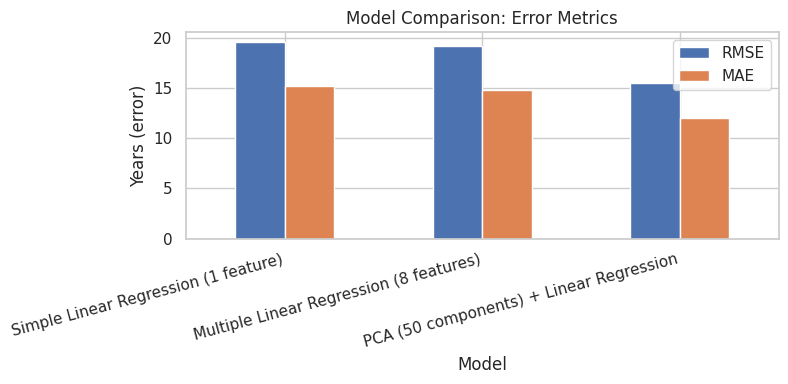

In [17]:
results.set_index('Model')[['RMSE', 'MAE']].plot(kind='bar', figsize=(8,4))
plt.title("Model Comparison: Error Metrics")
plt.ylabel("Years (error)")
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


## 6. สรุปผลและอภิปราย

- **Simple Linear Regression** ใช้ feature เดียว (ค่าความเข้มพิกเซลเฉลี่ย) ซึ่งไม่มีความสัมพันธ์เชิงเส้นที่แข็งแรงกับอายุมากนัก
  จึงมักได้ค่า R² ต่ำ และ error สูง — สะท้อนว่าภาพใบหน้าคนมี "ข้อมูล" ที่ซับซ้อนเกินกว่าจะสรุปด้วยตัวเลขเดียว
- **Multiple Linear Regression** เพิ่ม features เชิงสถิติของภาพ (mean/std/quadrant) ทำให้โมเดลมีข้อมูลมากขึ้น
  โดยทั่วไปควรให้ผลลัพธ์ (R² สูงขึ้น, RMSE ต่ำลง) ดีกว่า Simple LR
- **PCA + Linear Regression** ใช้ข้อมูลพิกเซลทั้งภาพ (ลดมิติด้วย PCA เพื่อคงข้อมูลสำคัญและลด overfitting/เวลาคำนวณ)
  มักให้ผลลัพธ์ดีที่สุดในกลุ่ม Linear Regression เนื่องจากสามารถจับรายละเอียดของภาพได้มากกว่า features แบบ manual

> **ข้อสังเกต:** Linear Regression เป็นโมเดลพื้นฐาน การทำนายอายุจากภาพใบหน้าจริง ๆ เป็นปัญหาที่ไม่เป็นเชิงเส้นสูง (non-linear)
> ในทางปฏิบัติมักใช้ CNN (Convolutional Neural Network) ถึงจะได้ผลลัพธ์ที่แม่นยำ แต่แล็บนี้มุ่งให้เข้าใจ **หลักการพื้นฐาน**
> ของ Regression, การเตรียมข้อมูล, และการใช้ PCA ก่อนต่อยอดไปโมเดลที่ซับซ้อนขึ้นในบทถัดไป

